# PX4 Phase 1 Rate Dynamics PINN Training v3 Physics

Train the multi-run nominal local dynamics model from PX4 Standard VTOL rate/thrust data with a lightweight physics-informed loss.

Model contract:

```text
x_t, u_t, prev_u_t, du_t, dt_s -> dx_t
```

Compared with v2:

- validation split is rebuilt from the nominal pool instead of holding out only a coupled scenario
- `N11_mixed_sequence` remains the hard rollout test scenario
- adds physics-informed consistency terms:
  - altitude kinematics: `d(relative_altitude) / dt ~= -vel_down`
  - Euler kinematics from body rates: `roll/pitch/yaw` deltas should agree with `p/q/r`
- keeps the output checkpoint contract compatible with later MPC work


In [1]:
# Colab setup
from pathlib import Path
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
torch: 2.10.0+cu128


In [2]:
# Dataset path
# Option A: set this manually after copying the processed folder into Drive.
DATASET_DIR = ''  # e.g. '/content/drive/MyDrive/PX4_Datasets/px4_phase1_rate_dynamics_dataset_v2_multirun_20260506_190000'

# Option B: automatically search common locations.
def find_latest_dataset_dir():
    patterns = [
        '/content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
        '/content/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
        './px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
    ]
    matches = []
    import glob
    for pat in patterns:
        matches.extend(glob.glob(pat, recursive=True))
    matches = sorted(set(matches))
    matches = [Path(m) for m in matches if (Path(m) / 'train.csv').exists()]
    if not matches:
        raise FileNotFoundError(
            'No processed dataset found. Set DATASET_DIR to the folder containing train.csv/val.csv/test.csv.'
        )
    return matches[-1]

DATASET_PATH = Path(DATASET_DIR) if DATASET_DIR else find_latest_dataset_dir()
print('DATASET_PATH:', DATASET_PATH)
print('files:', sorted([p.name for p in DATASET_PATH.iterdir()])[:20])


DATASET_PATH: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024
files: ['all_samples.csv', 'dataset_summary.csv', 'filter_report.csv', 'metadata.json', 'source_summary.csv', 'test.csv', 'train.csv', 'val.csv']


In [3]:
# Load processed CSVs and rebuild a more nominal validation split
base_train = pd.read_csv(DATASET_PATH / 'train.csv')
base_val = pd.read_csv(DATASET_PATH / 'val.csv')
base_test = pd.read_csv(DATASET_PATH / 'test.csv')
all_df = pd.read_csv(DATASET_PATH / 'all_samples.csv') if (DATASET_PATH / 'all_samples.csv').exists() else pd.concat([base_train, base_val, base_test], ignore_index=True)

metadata = {}
if (DATASET_PATH / 'metadata.json').exists():
    metadata = json.loads((DATASET_PATH / 'metadata.json').read_text())

state_cols = metadata.get('state_cols') or [c.removeprefix('dx_') for c in all_df.columns if c.startswith('dx_')]
action_cols = metadata.get('action_cols') or [c.removeprefix('u_') for c in all_df.columns if c.startswith('u_')]

feature_cols = (
    [f'x_{c}' for c in state_cols]
    + [f'u_{c}' for c in action_cols]
    + [f'prev_u_{c}' for c in action_cols]
    + [f'du_{c}' for c in action_cols]
    + ['dt_s']
)
target_cols = [f'dx_{c}' for c in state_cols]
next_cols = [f'x_next_{c}' for c in state_cols]

missing = [c for c in feature_cols + target_cols if c not in all_df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

# v2 used N10 as a full validation scenario, which can make early stopping depend on
# one unusual coupled case. For v3, keep a hard mixed sequence test set, and sample
# validation from the broader nominal pool. This makes validation more representative
# of ordinary training behavior while test still checks harder rollout generalization.
RESPLIT_FOR_NOMINAL_VALIDATION = True
TEST_SCENARIOS = ['N11_mixed_sequence']
VAL_FRACTION = 0.15

if RESPLIT_FOR_NOMINAL_VALIDATION:
    rng = np.random.default_rng(SEED)
    test_mask = all_df['scenario'].isin(TEST_SCENARIOS) if 'scenario' in all_df.columns else pd.Series(False, index=all_df.index)
    test_df = all_df[test_mask].copy()
    pool_df = all_df[~test_mask].copy()
    val_indices = []
    group_cols = [c for c in ['source_run', 'scenario'] if c in pool_df.columns]
    if group_cols:
        for _, group in pool_df.groupby(group_cols, sort=False):
            n_val = max(1, int(round(len(group) * VAL_FRACTION))) if len(group) >= 20 else 0
            if n_val:
                val_indices.extend(rng.choice(group.index.to_numpy(), size=n_val, replace=False).tolist())
    else:
        n_val = int(round(len(pool_df) * VAL_FRACTION))
        val_indices = rng.choice(pool_df.index.to_numpy(), size=n_val, replace=False).tolist()
    val_df = pool_df.loc[sorted(val_indices)].copy()
    train_df = pool_df.drop(index=val_df.index).copy()
else:
    train_df, val_df, test_df = base_train, base_val, base_test

print('train/val/test rows:', len(train_df), len(val_df), len(test_df))
print('state_cols:', state_cols)
print('action_cols:', action_cols)
print('n_features:', len(feature_cols), 'n_targets:', len(target_cols))

display(pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
}))

if 'scenario' in train_df.columns:
    split_view = pd.concat([
        train_df.assign(split='train'),
        val_df.assign(split='val'),
        test_df.assign(split='test'),
    ])
    display(split_view.groupby(['split', 'scenario']).size().to_frame('rows').reset_index())


train/val/test rows: 5969 1055 899
state_cols: ['relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action_cols: ['ref_roll_rate_rad_s', 'ref_pitch_rate_rad_s', 'ref_yaw_rate_rad_s', 'ref_thrust']
n_features: 23 n_targets: 10


,split,rows
0,train,5969
1,val,1055
2,test,899


,split,scenario,rows
0,test,N11_mixed_sequence,899
1,train,N00_hover_hold_0p5192,509
2,train,N01_pitch_rate_doublet_5dps,323
3,train,N02_pitch_rate_doublet_10dps,594
4,train,N03_roll_rate_doublet_5dps,303
5,train,N04_roll_rate_doublet_10dps,592
6,train,N05_yaw_rate_doublet_10dps,594
7,train,N06_yaw_rate_doublet_20dps,594
8,train,N07_thrust_step_pm010,594
9,train,N08_thrust_step_pm020,594


,target,split,mean,std,min,max
0,dx_relative_altitude_m,train,-1.299431e-02,0.025179,-0.964001,0.042000
1,dx_vel_north_m_s,train,-3.132854e-04,0.006515,-0.060000,0.160000
2,dx_vel_east_m_s,train,-2.883230e-03,0.047576,-3.520000,0.190000
3,dx_vel_down_m_s,train,9.850896e-04,0.007760,-0.110000,0.390000
4,dx_roll_deg,train,-1.252829e-04,0.040256,-0.726146,0.619929
5,dx_pitch_deg,train,2.126630e-03,0.168045,-0.648688,12.628178
6,dx_yaw_deg,train,-4.555325e-03,0.112788,-6.195786,1.031631
7,dx_roll_rate_rad_s,train,2.344025e-05,0.003625,-0.105426,0.102651
8,dx_pitch_rate_rad_s,train,-9.292323e-06,0.003638,-0.111722,0.109920
9,dx_yaw_rate_rad_s,train,-2.816269e-05,0.002668,-0.042038,0.041572


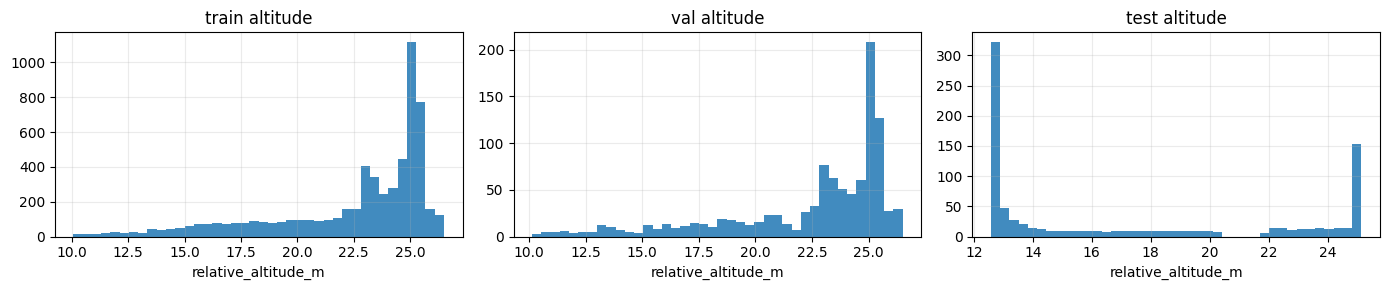

In [4]:
# Basic data sanity
def describe_targets(df, name):
    desc = df[target_cols].agg(['mean', 'std', 'min', 'max']).T
    desc.insert(0, 'split', name)
    return desc.reset_index().rename(columns={'index': 'target'})

display(pd.concat([
    describe_targets(train_df, 'train'),
    describe_targets(val_df, 'val'),
    describe_targets(test_df, 'test'),
], ignore_index=True))

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, df, title in zip(axes, [train_df, val_df, test_df], ['train', 'val', 'test']):
    ax.hist(df['x_relative_altitude_m'], bins=40, alpha=0.85)
    ax.set_title(f'{title} altitude')
    ax.set_xlabel('relative_altitude_m')
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [5]:
# Scaling and dataloaders
class StandardScaler:
    def __init__(self, mean, std):
        self.mean = np.asarray(mean, dtype=np.float32)
        self.std = np.asarray(std, dtype=np.float32)
        self.std = np.where(self.std < 1e-8, 1.0, self.std)

    @classmethod
    def fit(cls, arr):
        return cls(np.nanmean(arr, axis=0), np.nanstd(arr, axis=0))

    def transform(self, arr):
        return (np.asarray(arr, dtype=np.float32) - self.mean) / self.std

    def inverse_transform(self, arr):
        return np.asarray(arr, dtype=np.float32) * self.std + self.mean

    def to_dict(self, columns):
        return {'columns': list(columns), 'mean': self.mean.tolist(), 'std': self.std.tolist()}

X_train_raw = train_df[feature_cols].to_numpy(np.float32)
Y_train_raw = train_df[target_cols].to_numpy(np.float32)
X_val_raw = val_df[feature_cols].to_numpy(np.float32)
Y_val_raw = val_df[target_cols].to_numpy(np.float32)
X_test_raw = test_df[feature_cols].to_numpy(np.float32)
Y_test_raw = test_df[target_cols].to_numpy(np.float32)

x_scaler = StandardScaler.fit(X_train_raw)
y_scaler = StandardScaler.fit(Y_train_raw)

X_train = x_scaler.transform(X_train_raw)
Y_train = y_scaler.transform(Y_train_raw)
X_val = x_scaler.transform(X_val_raw)
Y_val = y_scaler.transform(Y_val_raw)
X_test = x_scaler.transform(X_test_raw)
Y_test = y_scaler.transform(Y_test_raw)

BATCH_SIZE = 1024
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(Y_train)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=False
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(Y_val)),
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

x_mean_t = torch.tensor(x_scaler.mean, dtype=torch.float32, device=device)
x_std_t = torch.tensor(x_scaler.std, dtype=torch.float32, device=device)
y_mean_t = torch.tensor(y_scaler.mean, dtype=torch.float32, device=device)
y_std_t = torch.tensor(y_scaler.std, dtype=torch.float32, device=device)
feature_index = {c: i for i, c in enumerate(feature_cols)}
target_index = {c: i for i, c in enumerate(target_cols)}
print('batches:', len(train_loader), len(val_loader))


batches: 6 2


In [6]:
# Model
class RateDynamicsMLP(nn.Module):
    def __init__(self, n_in, n_out, hidden=512, depth=5, dropout=0.02):
        super().__init__()
        layers = []
        last = n_in
        for _ in range(depth):
            layers += [nn.Linear(last, hidden), nn.SiLU(), nn.LayerNorm(hidden)]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            last = hidden
        layers.append(nn.Linear(last, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

MODEL_CONFIG = dict(hidden=512, depth=5, dropout=0.02)
model = RateDynamicsMLP(len(feature_cols), len(target_cols), **MODEL_CONFIG).to(device)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))


RateDynamicsMLP(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=512, bias=True)
    (1): SiLU()
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.02, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.02, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): SiLU()
    (14): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (15): Dropout(p=0.02, inplace=False)
    (16): Linear(in_features=512, out_features=512, bias=True)
    (17): SiLU()
    (18): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (19): Dropout(p=0.02, inplace=False)
    (20): Linear(in_features=512, out_features=1

epoch=001 train=0.57173 val=0.17651 val_data=0.17452 alt=0.017 euler=0.008 best_data=0.17452@1 lr=1.20e-03
epoch=020 train=0.07344 val=0.07817 val_data=0.07784 alt=0.002 euler=0.002 best_data=0.07784@20 lr=1.20e-03
epoch=040 train=0.06407 val=0.07226 val_data=0.07194 alt=0.003 euler=0.001 best_data=0.07141@38 lr=1.19e-03
epoch=060 train=0.06113 val=0.06878 val_data=0.06850 alt=0.002 euler=0.001 best_data=0.06773@53 lr=1.18e-03
epoch=080 train=0.05803 val=0.06590 val_data=0.06561 alt=0.002 euler=0.001 best_data=0.06554@69 lr=1.17e-03
epoch=100 train=0.05641 val=0.06614 val_data=0.06585 alt=0.003 euler=0.001 best_data=0.06518@91 lr=1.15e-03
epoch=120 train=0.05601 val=0.06664 val_data=0.06633 alt=0.003 euler=0.001 best_data=0.06513@112 lr=1.14e-03
epoch=140 train=0.05435 val=0.06571 val_data=0.06539 alt=0.003 euler=0.001 best_data=0.06513@112 lr=1.11e-03
epoch=160 train=0.05398 val=0.06580 val_data=0.06548 alt=0.003 euler=0.001 best_data=0.06513@112 lr=1.09e-03
epoch=180 train=0.05253 va

,epoch,train_loss,val_loss,train_data,val_data,train_alt_phy,val_alt_phy,train_euler_phy,val_euler_phy,lr
207,208,0.052085,0.065835,0.051807,0.065514,0.002606,0.002834,0.000869,0.001180,0.001012
208,209,0.051908,0.066194,0.051624,0.065843,0.002769,0.003164,0.000786,0.001221,0.001011
209,210,0.052017,0.066313,0.051741,0.065965,0.002666,0.003152,0.000786,0.001190,0.001009
210,211,0.051787,0.066356,0.051497,0.066026,0.002820,0.002929,0.000808,0.001198,0.001007
211,212,0.051923,0.066172,0.051644,0.065846,0.002753,0.002901,0.000733,0.001174,0.001005


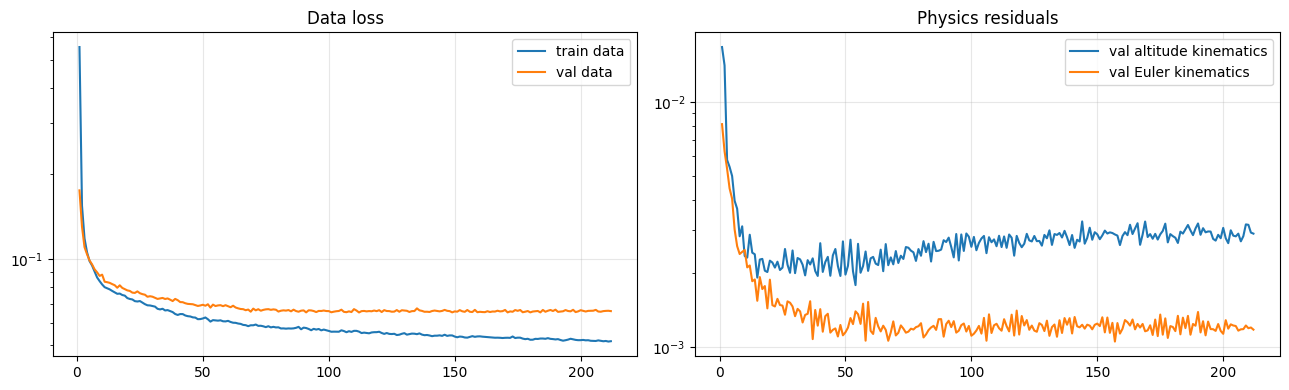

In [7]:
# Training with lightweight physics-informed loss
EPOCHS = 800
LR = 1.2e-3
WEIGHT_DECAY = 2e-5
PATIENCE = 100
GRAD_CLIP = 2.0

DATA_WEIGHT = 1.0
ALT_KIN_WEIGHT = 0.08
EULER_KIN_WEIGHT = 0.08
ALT_RESID_SCALE_M = 0.08
EULER_RESID_SCALE_RAD = np.deg2rad(0.6)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
data_loss_fn = nn.SmoothL1Loss(beta=0.5)

def raw_feature(xb_scaled, name):
    idx = feature_index[name]
    return xb_scaled[:, idx] * x_std_t[idx] + x_mean_t[idx]

def raw_pred_dx(pred_scaled, target_name):
    idx = target_index[target_name]
    return pred_scaled[:, idx] * y_std_t[idx] + y_mean_t[idx]

def physics_loss(xb_scaled, pred_scaled):
    dt = raw_feature(xb_scaled, 'dt_s').clamp_min(1e-4)

    # Altitude kinematics. PX4 NED vertical velocity is positive down, while
    # relative_altitude_m increases upward, so h_dot ~= -vel_down.
    vel_down = raw_feature(xb_scaled, 'x_vel_down_m_s')
    d_vel_down = raw_pred_dx(pred_scaled, 'dx_vel_down_m_s')
    vel_down_next = vel_down + d_vel_down
    expected_dh = -0.5 * (vel_down + vel_down_next) * dt
    pred_dh = raw_pred_dx(pred_scaled, 'dx_relative_altitude_m')
    alt_resid = (pred_dh - expected_dh) / ALT_RESID_SCALE_M
    alt_loss = torch.mean(alt_resid ** 2)

    # Euler kinematics from body rates. State angles are degrees, rates are rad/s.
    phi = torch.deg2rad(raw_feature(xb_scaled, 'x_roll_deg'))
    theta = torch.deg2rad(raw_feature(xb_scaled, 'x_pitch_deg')).clamp(-1.2, 1.2)
    p = raw_feature(xb_scaled, 'x_roll_rate_rad_s')
    q = raw_feature(xb_scaled, 'x_pitch_rate_rad_s')
    r = raw_feature(xb_scaled, 'x_yaw_rate_rad_s')

    tan_theta = torch.tan(theta)
    cos_theta = torch.cos(theta).clamp_min(0.2)
    sin_phi = torch.sin(phi)
    cos_phi = torch.cos(phi)

    phi_dot = p + tan_theta * (q * sin_phi + r * cos_phi)
    theta_dot = q * cos_phi - r * sin_phi
    psi_dot = (q * sin_phi + r * cos_phi) / cos_theta

    pred_dphi = torch.deg2rad(raw_pred_dx(pred_scaled, 'dx_roll_deg'))
    pred_dtheta = torch.deg2rad(raw_pred_dx(pred_scaled, 'dx_pitch_deg'))
    pred_dpsi = torch.deg2rad(raw_pred_dx(pred_scaled, 'dx_yaw_deg'))

    euler_resid = torch.stack([
        (pred_dphi - phi_dot * dt) / EULER_RESID_SCALE_RAD,
        (pred_dtheta - theta_dot * dt) / EULER_RESID_SCALE_RAD,
        (pred_dpsi - psi_dot * dt) / EULER_RESID_SCALE_RAD,
    ], dim=1)
    euler_loss = torch.mean(euler_resid ** 2)
    return alt_loss, euler_loss

def run_epoch(loader, train_mode):
    model.train(train_mode)
    totals = {'loss': 0.0, 'data': 0.0, 'alt': 0.0, 'euler': 0.0}
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        if train_mode:
            optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        data_loss = data_loss_fn(pred, yb)
        alt_loss, euler_loss = physics_loss(xb, pred)
        loss = DATA_WEIGHT * data_loss + ALT_KIN_WEIGHT * alt_loss + EULER_KIN_WEIGHT * euler_loss
        if train_mode:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        batch_n = len(xb)
        totals['loss'] += float(loss.detach().cpu()) * batch_n
        totals['data'] += float(data_loss.detach().cpu()) * batch_n
        totals['alt'] += float(alt_loss.detach().cpu()) * batch_n
        totals['euler'] += float(euler_loss.detach().cpu()) * batch_n
        n += batch_n
    return {k: v / max(n, 1) for k, v in totals.items()}

best_state = None
best_val = float('inf')
best_epoch = -1
history = []
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    scheduler.step()
    row = {
        'epoch': epoch,
        'train_loss': tr['loss'], 'val_loss': va['loss'],
        'train_data': tr['data'], 'val_data': va['data'],
        'train_alt_phy': tr['alt'], 'val_alt_phy': va['alt'],
        'train_euler_phy': tr['euler'], 'val_euler_phy': va['euler'],
        'lr': scheduler.get_last_lr()[0],
    }
    history.append(row)
    # Early stopping is based on data fit, not total weighted loss, to prevent
    # over-regularizing when physics weights are imperfect.
    monitor = va['data']
    if monitor < best_val:
        best_val = monitor
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 20 == 0 or epoch == 1:
        print(
            f"epoch={epoch:03d} train={tr['loss']:.5f} val={va['loss']:.5f} "
            f"val_data={va['data']:.5f} alt={va['alt']:.3f} euler={va['euler']:.3f} "
            f"best_data={best_val:.5f}@{best_epoch} lr={scheduler.get_last_lr()[0]:.2e}"
        )
    if epoch - best_epoch >= PATIENCE:
        print(f'early stop at epoch={epoch}, best_epoch={best_epoch}')
        break

model.load_state_dict(best_state)
print('training seconds:', round(time.time() - t0, 1))
hist_df = pd.DataFrame(history)
display(hist_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_data'], label='train data')
axes[0].plot(hist_df['epoch'], hist_df['val_data'], label='val data')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_title('Data loss')
axes[1].plot(hist_df['epoch'], hist_df['val_alt_phy'], label='val altitude kinematics')
axes[1].plot(hist_df['epoch'], hist_df['val_euler_phy'], label='val Euler kinematics')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_title('Physics residuals')
plt.tight_layout()
plt.show()


In [8]:
# One-step metrics in physical units
@torch.no_grad()
def predict_dx(df):
    x = x_scaler.transform(df[feature_cols].to_numpy(np.float32))
    preds = []
    model.eval()
    for i in range(0, len(x), 4096):
        xb = torch.tensor(x[i:i+4096], dtype=torch.float32, device=device)
        pred_scaled = model(xb).detach().cpu().numpy()
        preds.append(pred_scaled)
    pred_scaled = np.concatenate(preds, axis=0) if preds else np.zeros((0, len(target_cols)), dtype=np.float32)
    return y_scaler.inverse_transform(pred_scaled)

def one_step_metrics(df, split):
    pred = predict_dx(df)
    true = df[target_cols].to_numpy(np.float32)
    rows = []
    for j, col in enumerate(target_cols):
        err = pred[:, j] - true[:, j]
        rows.append({
            'split': split,
            'target': col,
            'rmse': float(np.sqrt(np.mean(err ** 2))),
            'mae': float(np.mean(np.abs(err))),
            'std_true': float(np.std(true[:, j])),
        })
    return pd.DataFrame(rows)

metrics_df = pd.concat([
    one_step_metrics(train_df, 'train'),
    one_step_metrics(val_df, 'val'),
    one_step_metrics(test_df, 'test'),
], ignore_index=True)
display(metrics_df)


,split,target,rmse,mae,std_true
0,train,dx_relative_altitude_m,0.019925,0.003454,0.025177
1,train,dx_vel_north_m_s,0.004134,0.001476,0.006514
2,train,dx_vel_east_m_s,0.045572,0.002923,0.047572
3,train,dx_vel_down_m_s,0.007016,0.002242,0.007760
4,train,dx_roll_deg,0.007205,0.001637,0.040253
5,train,dx_pitch_deg,0.160167,0.004099,0.168031
6,train,dx_yaw_deg,0.081188,0.006824,0.112778
7,train,dx_roll_rate_rad_s,0.001416,0.000325,0.003625
8,train,dx_pitch_rate_rad_s,0.001132,0.000304,0.003638
9,train,dx_yaw_rate_rad_s,0.000403,0.000258,0.002668


In [9]:
# Rollout sanity by scenario
def make_feature_row(state_vec, action_vec, prev_action_vec, dt_s):
    row = []
    row.extend(state_vec.tolist())
    row.extend(action_vec.tolist())
    row.extend(prev_action_vec.tolist())
    row.extend((action_vec - prev_action_vec).tolist())
    row.append(float(dt_s))
    return np.asarray(row, dtype=np.float32)

@torch.no_grad()
def rollout_scenario(df, scenario, max_steps=None):
    sdf = df[df['scenario'].eq(scenario)].sort_values('time_s').reset_index(drop=True)
    if max_steps is not None:
        sdf = sdf.iloc[:max_steps].copy()
    if len(sdf) < 2:
        return None
    true_x = sdf[[f'x_{c}' for c in state_cols]].to_numpy(np.float32)
    true_next = sdf[[f'x_next_{c}' for c in state_cols]].to_numpy(np.float32)
    actions = sdf[[f'u_{c}' for c in action_cols]].to_numpy(np.float32)
    prev_actions_logged = sdf[[f'prev_u_{c}' for c in action_cols]].to_numpy(np.float32)
    dts = sdf['dt_s'].to_numpy(np.float32)

    x_pred = true_x[0].copy()
    prev_action = prev_actions_logged[0].copy()
    pred_states = []
    for k in range(len(sdf)):
        feat = make_feature_row(x_pred, actions[k], prev_action, dts[k])
        feat_scaled = x_scaler.transform(feat[None, :])
        dx_scaled = model(torch.tensor(feat_scaled, dtype=torch.float32, device=device)).cpu().numpy()
        dx = y_scaler.inverse_transform(dx_scaled)[0]
        x_pred = x_pred + dx
        pred_states.append(x_pred.copy())
        prev_action = actions[k].copy()
    pred_states = np.asarray(pred_states)
    err = pred_states - true_next
    rows = []
    for j, col in enumerate(state_cols):
        rows.append({
            'scenario': scenario,
            'state': col,
            'rollout_rmse': float(np.sqrt(np.mean(err[:, j] ** 2))),
            'rollout_max_abs': float(np.max(np.abs(err[:, j]))),
            'steps': int(len(sdf)),
        })
    return pd.DataFrame(rows), sdf, pred_states, true_next

scenario_metrics = []
for scenario in sorted(test_df['scenario'].unique()):
    result = rollout_scenario(test_df, scenario)
    if result is None:
        continue
    m, _, _, _ = result
    scenario_metrics.append(m)
rollout_metrics_df = pd.concat(scenario_metrics, ignore_index=True)
display(rollout_metrics_df)


,scenario,state,rollout_rmse,rollout_max_abs,steps
0,N11_mixed_sequence,relative_altitude_m,3.168047,6.909793,899
1,N11_mixed_sequence,vel_north_m_s,0.983743,1.761396,899
2,N11_mixed_sequence,vel_east_m_s,1.220490,1.975387,899
3,N11_mixed_sequence,vel_down_m_s,0.193007,0.291214,899
4,N11_mixed_sequence,roll_deg,0.789289,2.411962,899
5,N11_mixed_sequence,pitch_deg,1.143666,2.288017,899
6,N11_mixed_sequence,yaw_deg,3.904600,8.091850,899
7,N11_mixed_sequence,roll_rate_rad_s,0.006807,0.062783,899
8,N11_mixed_sequence,pitch_rate_rad_s,0.006616,0.040261,899
9,N11_mixed_sequence,yaw_rate_rad_s,0.018663,0.048332,899


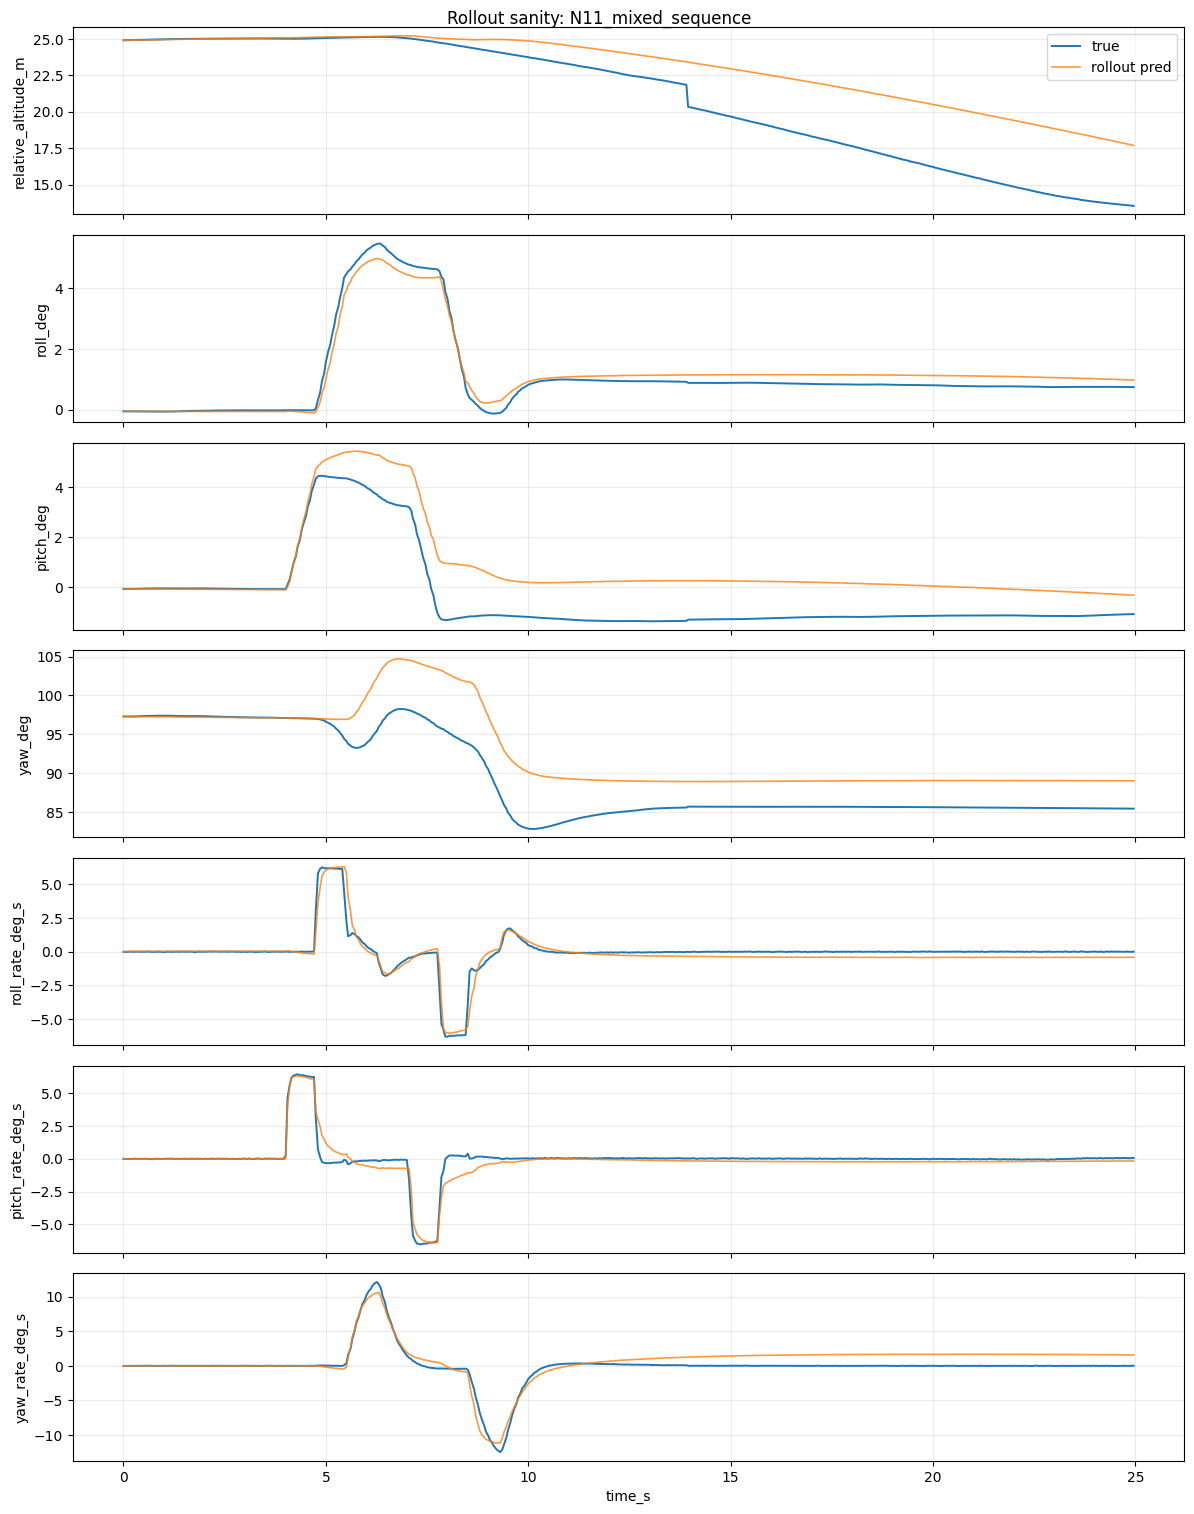

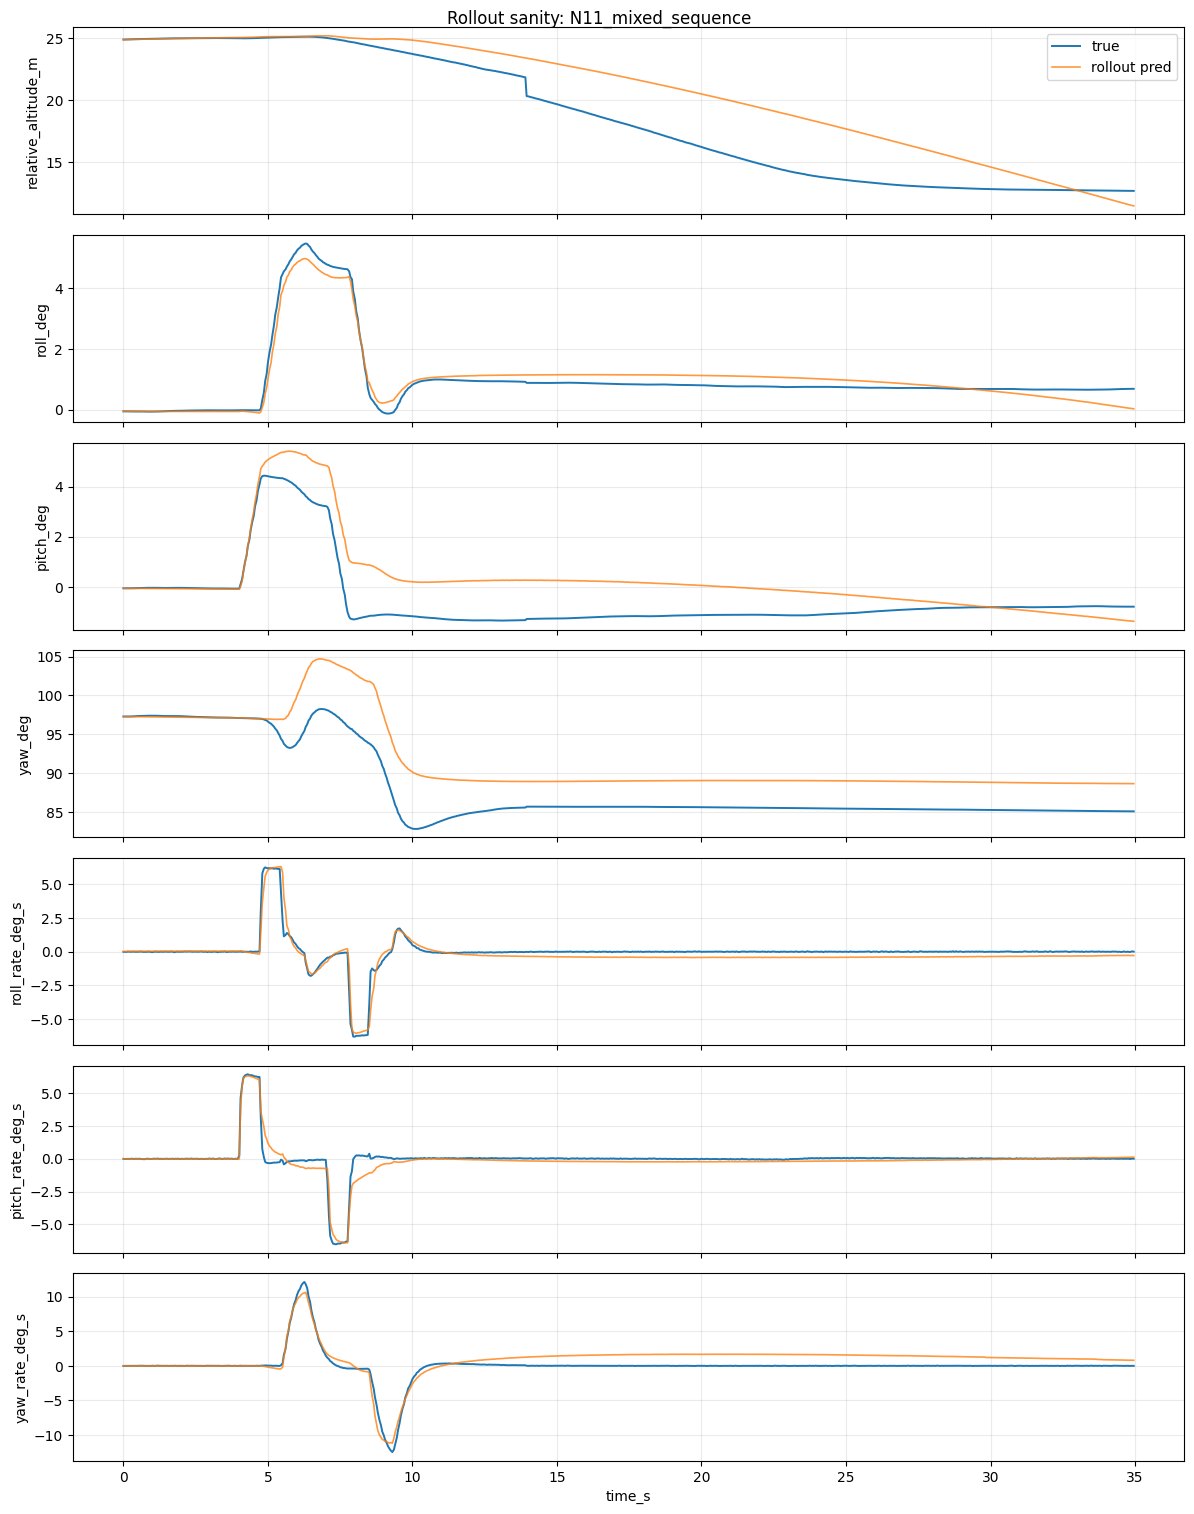

In [ ]:
# Plot selected rollout scenarios
def plot_rollout(df, scenario, max_steps=500):
    result = rollout_scenario(df, scenario, max_steps=max_steps)
    if result is None:
        print('not enough rows for', scenario)
        return
    _, sdf, pred_states, true_next = result
    t = sdf['time_s'].to_numpy()
    plot_states = ['relative_altitude_m', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
    n = len(plot_states)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.2 * n), sharex=True)
    for ax, state in zip(axes, plot_states):
        if state not in state_cols:
            continue
        j = state_cols.index(state)
        y_true = true_next[:, j]
        y_pred = pred_states[:, j]
        if state.endswith('_rad_s'):
            y_true = np.rad2deg(y_true)
            y_pred = np.rad2deg(y_pred)
            label = state.replace('_rad_s', '_deg_s')
        else:
            label = state
        ax.plot(t, y_true, label='true', lw=1.4)
        ax.plot(t, y_pred, label='rollout pred', lw=1.2, alpha=0.8)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.25)
    axes[0].legend(loc='best')
    axes[-1].set_xlabel('time_s')
    fig.suptitle(f'Rollout sanity: {scenario}')
    plt.tight_layout()
    plt.show()

for scenario in sorted(test_df['scenario'].unique())[:4]:
    plot_rollout(test_df, scenario, max_steps=500)

if 'N11_mixed_sequence' in set(test_df['scenario']):
    plot_rollout(test_df, 'N11_mixed_sequence', max_steps=700)


In [ ]:
# Save checkpoint for future MPC experiments
SAVE_ROOT = Path('/content/drive/MyDrive/PX4_Phase1_Models') if IN_COLAB else DATASET_PATH / 'models'
SAVE_ROOT.mkdir(parents=True, exist_ok=True)
stamp = time.strftime('%Y%m%d_%H%M%S')
ckpt_path = SAVE_ROOT / f'px4_phase1_rate_dynamics_mlp_v3_physics_{stamp}.pt'

checkpoint = {
    'model_version': 'px4_phase1_rate_dynamics_mlp_v3_physics',
    'state_dict': model.state_dict(),
    'model_config': {
        'n_in': len(feature_cols),
        'n_out': len(target_cols),
        **MODEL_CONFIG,
    },
    'loss_config': {
        'data_weight': DATA_WEIGHT,
        'alt_kin_weight': ALT_KIN_WEIGHT,
        'euler_kin_weight': EULER_KIN_WEIGHT,
        'alt_resid_scale_m': ALT_RESID_SCALE_M,
        'euler_resid_scale_rad': float(EULER_RESID_SCALE_RAD),
        'validation_policy': 'nominal_pool_random_validation_with_N11_mixed_test',
    },
    'feature_cols': feature_cols,
    'target_cols': target_cols,
    'state_cols': state_cols,
    'action_cols': action_cols,
    'x_scaler': x_scaler.to_dict(feature_cols),
    'y_scaler': y_scaler.to_dict(target_cols),
    'dataset_path': str(DATASET_PATH),
    'metadata': metadata,
    'history': hist_df.to_dict(orient='records'),
    'one_step_metrics': metrics_df.to_dict(orient='records'),
    'rollout_metrics': rollout_metrics_df.to_dict(orient='records'),
}
torch.save(checkpoint, ckpt_path)
print('saved:', ckpt_path)


saved: /content/drive/MyDrive/PX4_Phase1_Models/px4_phase1_rate_dynamics_mlp_v3_physics_20260506_101516.pt


In [ ]:
# Minimal load check
loaded = torch.load(ckpt_path, map_location='cpu')
print('loaded keys:', sorted(loaded.keys()))
print('feature count:', len(loaded['feature_cols']))
print('target count:', len(loaded['target_cols']))


loaded keys: ['action_cols', 'dataset_path', 'feature_cols', 'history', 'loss_config', 'metadata', 'model_config', 'model_version', 'one_step_metrics', 'rollout_metrics', 'state_cols', 'state_dict', 'target_cols', 'x_scaler', 'y_scaler']
feature count: 23
target count: 10
